# WLASL-100 Sign Language Recognition — Training Notebook

Trains a skeleton-based Transformer classifier on the **WLASL100** subset (100 ASL sign
classes) for the Sign Language Recognition (SLR) component of a larger assistive pipeline
(SLR → LLM sentence correction → gender-matched TTS).

**Approach:** MediaPipe pose + two-hand keypoints (not raw video pixels) → Transformer
encoder → 100-way classifier. This is far more data-efficient than a video CNN/ViT backbone
given WLASL100 has only ~2,000 training clips, and is cheap enough to also run on CPU at
deployment time.


---
## Contents
0. Setup (Drive, dependencies, GPU check)
1. Get the WLASL100 dataset
2. Model code (shared with `sign_language_model.py`)
3. Keypoint extraction & caching
4. Dataset class & augmentation
5. Training loop
6. Training curves
7. Evaluation (accuracy, per-class precision/recall)
8. Save artifacts to Drive
9. Inference sanity check


## 0. Setup

Mount Google Drive (used to persist the trained checkpoint + cached features across
sessions) and check what compute we got.

In [ ]:
# mount Google Drive to access the project directory and save artifacts
from google.colab import drive
drive.mount('/content/drive')
import os
DRIVE_PROJECT_DIR = '/content/drive/MyDrive/wlasl100_slr'
os.makedirs(DRIVE_PROJECT_DIR, exist_ok=True)
os.makedirs(f'{DRIVE_PROJECT_DIR}/checkpoints', exist_ok=True)
print('Artifacts will be saved under:', DRIVE_PROJECT_DIR)

Mounted at /content/drive
Artifacts will be saved under: /content/drive/MyDrive/wlasl100_slr


In [ ]:
# check if GPU is available and print the device name
import torch
print('PyTorch:', torch.__version__)
print('CUDA available:', torch.cuda.is_available())
if torch.cuda.is_available():
    print('GPU:', torch.cuda.get_device_name(0))
else:
    print('No GPU detected -- training will use CPU. This still works for WLASL100, just slower per epoch.')

PyTorch: 2.11.0+cu128
CUDA available: True
GPU: Tesla T4


Install the packages Colab doesn't already ship with. (`torch`, `numpy`, `opencv`
are preinstalled on Colab

In [ ]:
# install required packages 
!pip install -q mediapipe==0.10.32 kaggle pyyaml
print('done')

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.3/10.3 MB 79.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 137.4/137.4 kB 14.4 MB/s eta 0:00:00
done


## 1. Get the WLASL100 dataset

WLASL100 = the 100 most frequent gloss (word) classes out of the full 2,000-class WLASL
dataset, as defined in the original paper (Li et al., WACV 2020).

**Kaggle mirror.** The original dataset requires downloading ~2,000
individual YouTube clips, many of which now 404 (dead links) . A community Kaggle mirror (`risangbaskoro/wlasl-processed`) hosts the already
-downloaded videos plus the same official metadata files (`WLASL_v0.3.json`, `nslt_100.json`,
`wlasl_class_list.txt`), so we use that here.


**fallback, slower:** the official downloader at
https://github.com/dxli94/WLASL/tree/master/start_kit (`video_downloader.py`, uses `yt-dlp`)
if you'd rather source videos directly and can tolerate missing/dead links. Not included
here to keep this notebook self-contained and fast 

In [ ]:
# set up Kaggle credentials for downloading datasets
from google.colab import files
import os

if not os.path.exists('/root/.kaggle/kaggle.json'):
    print('Upload your kaggle.json now:')
    uploaded = files.upload()
    os.makedirs('/root/.kaggle', exist_ok=True)
    for fname in uploaded:
        os.rename(fname, '/root/.kaggle/kaggle.json')
    os.chmod('/root/.kaggle/kaggle.json', 0o600)
print('Kaggle credentials ready.')

Upload your kaggle.json now:


Saving kaggle.json to kaggle.json
Kaggle credentials ready.


In [ ]:
# download the WLASL-processed dataset from Kaggle
DATA_DIR = '/content/wlasl_data'
os.makedirs(DATA_DIR, exist_ok=True)
!kaggle datasets download -d risangbaskoro/wlasl-processed -p {DATA_DIR} --unzip
print('Download complete. Contents:')
!ls {DATA_DIR}

Dataset URL: https://www.kaggle.com/datasets/risangbaskoro/wlasl-processed
License(s): other
100% 4.82G/4.82G [00:59<00:00, 86.3MB/s]

Download complete. Contents:
missing.txt	nslt_100.json	nslt_300.json  wlasl_class_list.txt
nslt_1000.json	nslt_2000.json	videos	       WLASL_v0.3.json


Locate the metadata files and the videos folder (the exact folder layout has varied
slightly across mirror versions, so we search for them rather than hardcoding paths).

In [ ]:
# verify that the expected files are present
import glob
# find a single file matching the given pattern under DATA_DIR, or raise an error if not found
def find_one(pattern):
    matches = glob.glob(f'{DATA_DIR}/**/{pattern}', recursive=True)
    if not matches:
        raise FileNotFoundError(f"Could not find a file matching '{pattern}' under {DATA_DIR}. "
                                 f"Check the dataset download above completed successfully.")
    return matches[0]
# find the paths to the required files
NSLT_100_PATH = find_one('nslt_100.json')
CLASS_LIST_PATH = find_one('wlasl_class_list.txt')
videos_dirs = glob.glob(f'{DATA_DIR}/**/videos', recursive=True)
VIDEOS_DIR = videos_dirs[0] if videos_dirs else os.path.dirname(NSLT_100_PATH)
# print some basic stats about the dataset
print('nslt_100.json  ->', NSLT_100_PATH)
print('class list     ->', CLASS_LIST_PATH)
print('videos dir     ->', VIDEOS_DIR)
print('num video files found:', len(glob.glob(f'{VIDEOS_DIR}/*.mp4')))

nslt_100.json  -> /content/wlasl_data/nslt_100.json
class list     -> /content/wlasl_data/wlasl_class_list.txt
videos dir     -> /content/wlasl_data/videos
num video files found: 11980


In [ ]:
# Load the nslt_100.json file and print some basic stats
import json
with open(NSLT_100_PATH) as f:
    nslt_100 = json.load(f)
# schema: {video_id: {"subset": "train"/"val"/"test","action": [class_id, frame_start, frame_end]}}
example_key = next(iter(nslt_100))
print('Example entry:', example_key, '->', nslt_100[example_key])
print('Total instances in nslt_100.json:', len(nslt_100))
# Count the number of instances in each subset (train, val, test)
subset_counts = {}
for v in nslt_100.values():
    subset_counts[v['subset']] = subset_counts.get(v['subset'], 0) + 1
print('Subset counts:', subset_counts)

Example entry: 05237 -> {'subset': 'train', 'action': [77, 1, 55]}
Total instances in nslt_100.json: 2038
Subset counts: {'train': 1442, 'val': 338, 'test': 258}


In [ ]:
# class_id (int, 0-99) -> gloss string, from wlasl_class_list.txt ("<index>\t<gloss>" per line)
class_id_to_gloss = {}
with open(CLASS_LIST_PATH) as f:
    for line in f:
        parts = line.strip().split('\t') if '\t' in line else line.strip().split(None, 1)
        if len(parts) != 2:
            continue
        idx, gloss = parts
        class_id_to_gloss[int(idx)] = gloss
# Verify that the class IDs referenced in nslt_100.json are all present in the class list
used_class_ids = sorted({v['action'][0] for v in nslt_100.values()})
print('Number of distinct classes referenced in nslt_100.json:', len(used_class_ids))
assert len(used_class_ids) == 100, (
    f"Expected 100 classes for WLASL100, found {len(used_class_ids)}. "
    f"Double-check NSLT_100_PATH points at the 100-class split file, not 300/1000/2000."
)
# Create a label map: label index (0-99) -> gloss string, and a reverse mapping: class_id -> label index
label_map = {str(i): class_id_to_gloss[cid] for i, cid in enumerate(used_class_ids)}
class_id_to_label_index = {cid: i for i, cid in enumerate(used_class_ids)}
print('Sample label_map entries:', dict(list(label_map.items())[:5]))

Number of distinct classes referenced in nslt_100.json: 100
Sample label_map entries: {'0': 'book', '1': 'drink', '2': 'computer', '3': 'before', '4': 'chair'}


In [9]:
# Resolve each nslt_100 entry to an actual video file on disk (filenames vary: "12345.mp4"
# or zero-padded "00123.mp4" across mirror versions) and drop entries whose video is missing.
def resolve_video_path(video_id: str):
    candidates = [
        f'{VIDEOS_DIR}/{video_id}.mp4',
        f'{VIDEOS_DIR}/{int(video_id):05d}.mp4',
        f'{VIDEOS_DIR}/{int(video_id):06d}.mp4',
    ]
    for c in candidates:
        if os.path.exists(c):
            return c
    return None

instances = []  # list of dicts: video_id, path, label_index, subset, frame_start, frame_end
missing = 0
for video_id, meta in nslt_100.items():
    path = resolve_video_path(video_id)
    if path is None:
        missing += 1
        continue
    class_id, frame_start, frame_end = meta['action']
    instances.append({
        'video_id': video_id,
        'path': path,
        'label_index': class_id_to_label_index[class_id],
        'subset': meta['subset'],
        'frame_start': frame_start,
        'frame_end': frame_end,
    })

print(f'Resolved {len(instances)} / {len(nslt_100)} instances to a video file on disk '
      f'({missing} missing).')

Resolved 1013 / 2038 instances to a video file on disk (1025 missing).


In [ ]:
from collections import Counter
# Count how many videos are present/missing for each class
present_by_class = Counter()
missing_by_class = Counter()
for video_id, meta in nslt_100.items():
    class_id = meta['action'][0]
    if resolve_video_path(video_id) is not None:
        present_by_class[class_id] += 1
    else:
        missing_by_class[class_id] += 1
# Report on classes with zero or low coverage
zero_coverage = [cid for cid in used_class_ids if present_by_class.get(cid, 0) == 0]
low_coverage = [cid for cid in used_class_ids if 0 < present_by_class.get(cid, 0) < 3]

print(f'Overall: {missing}/{len(nslt_100)} missing ({missing / len(nslt_100):.1%})')
print(f'Classes with ZERO videos available: {len(zero_coverage)}')
if zero_coverage:
    print('  ->', [class_id_to_gloss[c] for c in zero_coverage])
print(f'Classes with fewer than 3 videos available: {len(low_coverage)}')
if low_coverage:
    print('  ->', [class_id_to_gloss[c] for c in low_coverage])
print()
if zero_coverage or len(low_coverage) > 10:
    print('Several classes are poorly covered by this mirror -- see Option B (try a second '
          'mirror) and Option C (official precomputed keypoints, no video download at all) '
          'below before training.')
else:
    print('Coverage looks workable -- every class has at least a few examples. You can '
          'proceed to Section 2 directly, or still use Option C below to skip the (slow, '
          'CPU-bound) keypoint extraction step in Section 3 entirely.')

Overall: 1025/2038 missing (50.3%)
Classes with ZERO videos available: 0
Classes with fewer than 3 videos available: 0

Coverage looks workable -- every class has at least a few examples. You can proceed to Section 2 directly, or still use Option C below to skip the (slow, CPU-bound) keypoint extraction step in Section 3 entirely.


### try a second Kaggle mirror to fill gaps

Different community mirrors were scraped at different times, so a video missing from one may
still be present in another. This merges in any videos `sttaseen/wlasl2000-resized` has that
the first mirror didn't.

In [ ]:
#Try a second mirror of the WLASL2000 dataset, which may have better coverage for some classes
DATA_DIR_2 = '/content/wlasl_data_2'
os.makedirs(DATA_DIR_2, exist_ok=True)
!kaggle datasets download -d sttaseen/wlasl2000-resized -p {DATA_DIR_2} --unzip
videos_dirs_2 = glob.glob(f'{DATA_DIR_2}/**/videos', recursive=True) or glob.glob(f'{DATA_DIR_2}/**/*.mp4', recursive=True)
print('Second mirror videos found under:', videos_dirs_2[:1] if videos_dirs_2 else 'none found')

Dataset URL: https://www.kaggle.com/datasets/sttaseen/wlasl2000-resized
License(s): other
100% 1.87G/1.87G [00:26<00:00, 76.9MB/s]

Second mirror videos found under: ['/content/wlasl_data_2/wlasl-complete/videos']


In [ ]:
# Find the directory containing videos in the second mirror
VIDEOS_DIR_2 = os.path.dirname(glob.glob(f'{DATA_DIR_2}/**/*.mp4', recursive=True)[0]) \
    if glob.glob(f'{DATA_DIR_2}/**/*.mp4', recursive=True) else None
# Define a function to resolve video paths using both mirrors
def resolve_video_path_v2(video_id: str):
    path = resolve_video_path(video_id)
    if path is not None:
        return path
    if VIDEOS_DIR_2 is None:
        return None
    for cand in (f'{VIDEOS_DIR_2}/{video_id}.mp4', f'{VIDEOS_DIR_2}/{int(video_id):05d}.mp4'):
        if os.path.exists(cand):
            return cand
    return None
# Rebuild instances using both mirrors
instances = []
still_missing = 0
# we'll try to resolve each video_id using the first mirror, and if not found, try the second mirror
for video_id, meta in nslt_100.items():
    path = resolve_video_path_v2(video_id)
    if path is None:
        still_missing += 1
        continue
    class_id, frame_start, frame_end = meta['action']
    instances.append({
        'video_id': video_id, 'path': path, 'label_index': class_id_to_label_index[class_id],
        'subset': meta['subset'], 'frame_start': frame_start, 'frame_end': frame_end,
    })
print(f'After merging both mirrors: {len(instances)} / {len(nslt_100)} resolved '
      f'({still_missing} still missing).')

After merging both mirrors: 2038 / 2038 resolved (0 still missing).


In [ ]:
import pandas as pd
from collections import Counter
from IPython.display import display
# Count the number of instances in each subset (train, val, test)
counts_by_class = Counter(inst['label_index'] for inst in instances)
# Create a DataFrame to display coverage information
rows = [
    {'label_index': i, 'gloss': label_map[str(i)], 'num_videos': counts_by_class.get(i, 0)}
    for i in range(len(label_map))
]
coverage_df = pd.DataFrame(rows).sort_values('num_videos').reset_index(drop=True)
# Report on classes with zero or low coverage
print(f"Classes with 0 videos:   {(coverage_df['num_videos'] == 0).sum()}")
print(f"Classes with < 3 videos: {(coverage_df['num_videos'] < 3).sum()}")
print(f"Classes with < 5 videos: {(coverage_df['num_videos'] < 5).sum()}")
print(f"Min / median / max videos per class: {coverage_df['num_videos'].min()} / "
      f"{coverage_df['num_videos'].median():.0f} / {coverage_df['num_videos'].max()}")
display(coverage_df)  # full 100-row table, sorted worst-covered first

Classes with 0 videos:   0
Classes with < 3 videos: 0
Classes with < 5 videos: 0
Min / median / max videos per class: 18 / 20 / 40


,label_index,gloss,num_videos
0,80,but,18
1,81,cheat,18
2,82,city,18
3,83,cook,18
4,84,decide,18
...,...,...,...
95,5,go,26
96,4,chair,26
97,2,computer,30
98,1,drink,35


## 2.Model code

In [ ]:
%%writefile sign_language_model.py
"""
sign_language_model.py
=======================

Core module for the WLASL-100 Sign Language Recognition (SLR) component.

This file defines:
  1. `SignLanguageTransformer`   - the neural network architecture (skeleton/keypoint based).
  2. `KeypointExtractor`         - wraps MediaPipe Tasks (PoseLandmarker + HandLandmarker) to turn
                                    raw video frames into normalized keypoint feature sequences.
  3. `SignLanguageRecognizer`    - a "never-raises" inference interface used by the rest of the
                                    pipeline (LLM text correction, TTS, etc). Loads a trained
                                    checkpoint + label map and exposes `.predict(...)`.

Design notes
------------
- Input representation: MediaPipe **pose (33 landmarks)** + **left hand (21)** + **right hand (21)**
  keypoints, each with (x, y, z), plus 2 binary hand-presence flags -> 227-dim feature per frame.
  This is a *skeleton-based* approach rather than raw-pixel CNN/ViT features. For an isolated,
  100-class, ~2k-clip dataset like WLASL100, skeleton features are dramatically more
  data-efficient and orders of magnitude cheaper to run than a video CNN/ViT backbone, which is
  what lets this model run comfortably on CPU.
- Sequences are resampled to a fixed length (`sequence_length`, default 64 frames) via linear
  interpolation, so clips of any original duration/frame-rate are handled uniformly.
- The inference interface never raises: every public method returns a result dict with a
  `success` flag and an `error` field on failure, matching the "never-raises service contract"
  convention used by the other components in this pipeline (LLM correction, TTS).
"""

from __future__ import annotations

import json
import math
import os
import urllib.request
from dataclasses import dataclass, field
from typing import Any, Dict, List, Optional, Tuple

import numpy as np
import torch
import torch.nn as nn

# --------------------------------------------------------------------------------------
# Constants describing the keypoint feature layout
# --------------------------------------------------------------------------------------
NUM_POSE_LANDMARKS = 33
NUM_HAND_LANDMARKS = 21
COORDS_PER_LANDMARK = 3  # x, y, z
# pose(33*3) + left_hand(21*3) + right_hand(21*3) + 2 hand-presence flags
FEATURE_DIM = (
    NUM_POSE_LANDMARKS * COORDS_PER_LANDMARK
    + 2 * NUM_HAND_LANDMARKS * COORDS_PER_LANDMARK
    + 2
)  # = 227

# model URLs for MediaPipe Tasks (PoseLandmarker + HandLandmarker) 
MEDIAPIPE_POSE_MODEL_URL = (
    "https://storage.googleapis.com/mediapipe-models/pose_landmarker/"
    "pose_landmarker_lite/float16/1/pose_landmarker_lite.task"
)
MEDIAPIPE_HAND_MODEL_URL = (
    "https://storage.googleapis.com/mediapipe-models/hand_landmarker/"
    "hand_landmarker/float16/1/hand_landmarker.task"
)


# ========================================================================================
# 1. MODEL ARCHITECTURE
# ========================================================================================

# positional encoding using sinusoidal functions, as in the original Transformer paper
class PositionalEncoding(nn.Module):
    """Standard sinusoidal positional encoding added to the per-frame embeddings.""" 
    def __init__(self, d_model: int, max_len: int = 256):
        super().__init__() # initialize the nn.Module
        pe = torch.zeros(max_len, d_model) # create a tensor of shape (max_len, d_model) filled with zeros
        position = torch.arange(0, max_len, dtype=torch.float32).unsqueeze(1)
        # compute the division term for the sinusoidal functions
        div_term = torch.exp( 
            torch.arange(0, d_model, 2, dtype=torch.float32) * (-math.log(10000.0) / d_model)
        )
        # fill the positional encoding tensor with sine and cosine values for even and odd indices, respectively
        pe[:, 0::2] = torch.sin(position * div_term) # fill even indices with sine values
        pe[:, 1::2] = torch.cos(position * div_term[: pe[:, 1::2].shape[1]]) # fill odd indices with cosine values
        self.register_buffer("pe", pe.unsqueeze(0))  # (1, max_len, d_model) 
    # forward method adds the positional encoding to the input tensor x
    def forward(self, x: torch.Tensor) -> torch.Tensor:
        return x + self.pe[:, : x.size(1), :]

# attention pooling layer: a single learned query attends over the time dimension to produce a pooled summary
class AttentionPool(nn.Module):
    """A single learned query attends over the time dimension to produce a pooled summary.
    This is combined with mean pooling in the classifier head; attention pooling lets the
    model learn to emphasize the most discriminative frames of a sign (e.g. the peak hand
    configuration) instead of treating all frames -- including transition/rest frames -- equally.
    """
    
    # init method initializes the attention pooling layer with a learnable query vector and a scaling factor
    def __init__(self, d_model: int):
        super().__init__()
        self.query = nn.Parameter(torch.randn(1, 1, d_model) * 0.02)
        self.scale = d_model ** -0.5

    # forward method computes attention weights over the time dimension and returns a pooled summary
    def forward(self, x: torch.Tensor, key_padding_mask: Optional[torch.Tensor] = None) -> torch.Tensor:
        # x: (B, T, D); key_padding_mask: (B, T) True = ignore
        q = self.query.expand(x.size(0), -1, -1)  # (B, 1, D)
        scores = torch.bmm(q, x.transpose(1, 2)) * self.scale  # (B, 1, T)
        if key_padding_mask is not None:
            scores = scores.masked_fill(key_padding_mask.unsqueeze(1), float("-inf"))
        weights = torch.softmax(scores, dim=-1)
        pooled = torch.bmm(weights, x)  # (B, 1, D)
        return pooled.squeeze(1)

# the main transformer model for sign language recognition
class SignLanguageTransformer(nn.Module):
    """Transformer encoder over a sequence of per-frame skeleton keypoints.

    Input:  (B, T, input_dim) float tensor of normalized keypoints (see KeypointExtractor).
    Output: (B, num_classes) raw logits.
    The model is intentionally small (a few million parameters) so it runs with low latency
    on CPU as well as GPU -- appropriate given WLASL100's ~2,000 training clips, where a large
    model would overfit badly anyway.
    """

    def __init__(
        self,
        input_dim: int = FEATURE_DIM,  # input feature dimension (pose + hands + flags)
        d_model: int = 192,            # embedding dimension for the transformer
        nhead: int = 4,                # number of attention heads in the transformer
        num_layers: int = 4,           # number of transformer encoder layers
        dim_feedforward: int = 512,    # dimension of the feedforward network in the transformer encoder
        num_classes: int = 100,        # number of output classes (glosses)
        dropout: float = 0.2,          # dropout rate for the transformer and classifier
        max_seq_len: int = 128,        # maximum sequence length (for positional encoding)
    ):
        super().__init__()
        self.input_dim = input_dim
        self.num_classes = num_classes

        self.input_proj = nn.Sequential(
            nn.Linear(input_dim, d_model),   # project input features to d_model dimension
            nn.LayerNorm(d_model),           # normalize the projected features
            nn.Dropout(dropout),             # add dropout for regularization
        )
        self.pos_encoding = PositionalEncoding(d_model, max_len=max_seq_len) # add positional encoding to the projected features

        encoder_layer = nn.TransformerEncoderLayer(
            d_model=d_model,                       
            nhead=nhead,
            dim_feedforward=dim_feedforward,
            dropout=dropout,
            activation="gelu",             # use GELU activation function in the feedforward network
            batch_first=True,              # treat the first dimension as batch size (B, T, D) instead of (T, B, D) 
        )
        # create the transformer encoder with the specified number of layers
        self.encoder = nn.TransformerEncoder(encoder_layer, num_layers=num_layers)
        # attention pooling layer to summarize the sequence of embeddings into a single vector
        self.attn_pool = AttentionPool(d_model)
        # classifier head: combines attention-pooled and mean-pooled embeddings to produce logits for each class
        self.classifier = nn.Sequential(
            nn.Linear(d_model * 2, d_model),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(d_model, num_classes),
        )
    # forward method defines the forward pass of the model, taking in a batch of sequences and an optional key padding mask
    def forward(
        self, x: torch.Tensor, key_padding_mask: Optional[torch.Tensor] = None) -> torch.Tensor:
        """
        x: (B, T, input_dim)
        key_padding_mask: optional (B, T) bool tensor, True at positions to ignore
                           (e.g. frames where no landmarks were detected at all).
        """
        
        h = self.input_proj(x)        # project input features to d_model dimension
        h = self.pos_encoding(h)      # add positional encoding to the projected features
        h = self.encoder(h, src_key_padding_mask=key_padding_mask) # pass through the transformer encoder

        attn_pooled = self.attn_pool(h, key_padding_mask)     # attention-pooled summary of the sequence
        if key_padding_mask is not None:                      # mean-pool only the valid frames (not masked) to get a second summary of the sequence
            keep_mask = (~key_padding_mask).unsqueeze(-1).float()
            mean_pooled = (h * keep_mask).sum(1) / keep_mask.sum(1).clamp(min=1e-6)
        else:
            mean_pooled = h.mean(dim=1)
     
        combined = torch.cat([attn_pooled, mean_pooled], dim=-1) # concatenate the attention-pooled and mean-pooled summaries
        return self.classifier(combined)                         # pass through the classifier head to get logits for each class

    @property
    def num_parameters(self) -> int: # return the number of trainable parameters in the model
        return sum(p.numel() for p in self.parameters() if p.requires_grad)


# function to build a SignLanguageTransformer from a configuration dictionary (e.g., from a YAML file)
def build_model_from_config(model_cfg: Dict[str, Any]) -> SignLanguageTransformer:
    """Construct a SignLanguageTransformer from a `config.yaml`-style dict (the `model:` section)."""
    return SignLanguageTransformer(
        input_dim=model_cfg.get("input_dim", FEATURE_DIM),
        d_model=model_cfg.get("d_model", 192),
        nhead=model_cfg.get("nhead", 4),
        num_layers=model_cfg.get("num_layers", 4),
        dim_feedforward=model_cfg.get("dim_feedforward", 512),
        num_classes=model_cfg.get("num_classes", 100),
        dropout=model_cfg.get("dropout", 0.2),
        max_seq_len=model_cfg.get("max_seq_len", 128),
    )


# ========================================================================================
# 2. KEYPOINT EXTRACTION (MediaPipe Tasks: PoseLandmarker + HandLandmarker)
# ========================================================================================

def ensure_mediapipe_models(models_dir: str) -> Tuple[str, str]:
    """Download the MediaPipe pose/hand .task model bundles if not already present locally.

    Returns (pose_model_path, hand_model_path).
    """
    os.makedirs(models_dir, exist_ok=True)                            # create the models directory if it doesn't exist
    pose_path = os.path.join(models_dir, "pose_landmarker_lite.task") # create the full path for the pose model file
    hand_path = os.path.join(models_dir, "hand_landmarker.task")      # create the full path for the hand model file

    if not os.path.exists(pose_path):
        urllib.request.urlretrieve(MEDIAPIPE_POSE_MODEL_URL, pose_path)
    if not os.path.exists(hand_path):
        urllib.request.urlretrieve(MEDIAPIPE_HAND_MODEL_URL, hand_path)
    return pose_path, hand_path


@dataclass
class FrameKeypoints: # class to hold the result of keypoint extraction for a single frame
    """Result of running keypoint extraction on a single frame."""
    features: np.ndarray  # shape (FEATURE_DIM,) 
    hand_present: bool    # True if either hand was detected in this frame


class KeypointExtractor: # class to extract normalized pose and hand keypoints from video frames using MediaPipe Tasks
    """Extracts normalized pose + two-hand keypoints from video frames using MediaPipe Tasks.

    Uses `VIDEO` running mode (frame-by-frame with monotonically increasing timestamps), which
    is appropriate both for offline processing of pre-recorded clips (training/inference on a
    video file) and for sequential processing of a live camera feed frame-by-frame. For a fully
    asynchronous real-time pipeline, MediaPipe's `LIVE_STREAM` mode with a result callback is an
    alternative, but VIDEO mode keeps the calling code simple and synchronous, which is what most
    deployments of this component need.
    """

    def __init__(
        self,
        pose_model_path: str,
        hand_model_path: str,
        num_hands: int = 2,
        min_detection_confidence: float = 0.5,
        min_tracking_confidence: float = 0.5,
    ):
    
        import mediapipe as mp
        from mediapipe.tasks import python as mp_python
        from mediapipe.tasks.python import vision as mp_vision

        self._mp = mp
        self._VisionRunningMode = mp_vision.RunningMode

        pose_options = mp_vision.PoseLandmarkerOptions(
            base_options=mp_python.BaseOptions(model_asset_path=pose_model_path),
            running_mode=self._VisionRunningMode.VIDEO,
            min_pose_detection_confidence=min_detection_confidence,
            min_tracking_confidence=min_tracking_confidence,
        )
        hand_options = mp_vision.HandLandmarkerOptions(
            base_options=mp_python.BaseOptions(model_asset_path=hand_model_path),
            running_mode=self._VisionRunningMode.VIDEO,
            num_hands=num_hands,
            min_hand_detection_confidence=min_detection_confidence,
            min_tracking_confidence=min_tracking_confidence,
        )
        self._pose_landmarker = mp_vision.PoseLandmarker.create_from_options(pose_options)
        self._hand_landmarker = mp_vision.HandLandmarker.create_from_options(hand_options)
        self._closed = False
        # MediaPipe's VIDEO running mode requires timestamps to strictly increase for the
        # entire lifetime of the landmarker object -- not just within one clip. Since a single
        # KeypointExtractor is commonly reused across many videos (e.g. a training-set
        # extraction loop, or repeated SignLanguageRecognizer.predict() calls in production),
        # each of which naturally wants to count its own frames from 0, we track the last
        # timestamp actually given to MediaPipe and clamp every new one to be strictly greater
        # -- regardless of what the caller passes in. This makes the extractor safe to reuse
        # across any number of videos/streams without the caller having to manage a global
        # counter itself. See extract_from_frame().
        self._last_timestamp_ms = -1

    def reset_timestamp(self):
        """Optional: call this between logically-unrelated videos/streams if you want the
        next frame's timestamp to be treated as a fresh start for tracking purposes. Not
        required for correctness (extract_from_frame() guards monotonicity unconditionally
        either way) -- this only affects MediaPipe's internal tracking continuity, not
        whether it crashes."""
        self._last_timestamp_ms = -1

    # ---- internal helpers -------------------------------------------------------------

    @staticmethod
    def _landmarks_to_array(landmark_list, count: int) -> np.ndarray:
        arr = np.zeros((count, 3), dtype=np.float32)
        if landmark_list:
            for i, lm in enumerate(landmark_list[:count]):
                arr[i] = (lm.x, lm.y, lm.z)
        return arr

    @staticmethod
    def _normalize(pose: np.ndarray, left_hand: np.ndarray, right_hand: np.ndarray) -> np.ndarray:
        """Center on the shoulder midpoint and scale by shoulder width, so the features are
        invariant to the signer's position/distance from the camera. Falls back to an identity
        transform if shoulders weren't detected (all-zero pose)."""
        left_shoulder, right_shoulder = pose[11], pose[12]
        if np.allclose(left_shoulder, 0) and np.allclose(right_shoulder, 0):
            return np.concatenate([pose, left_hand, right_hand], axis=0)

        center = (left_shoulder + right_shoulder) / 2.0
        scale = np.linalg.norm(left_shoulder - right_shoulder)
        scale = scale if scale > 1e-6 else 1.0

        pose_n = (pose - center) / scale
        left_hand_n = (left_hand - center) / scale if left_hand.any() else left_hand
        right_hand_n = (right_hand - center) / scale if right_hand.any() else right_hand
        return np.concatenate([pose_n, left_hand_n, right_hand_n], axis=0)

    def _make_mp_image(self, frame_rgb: np.ndarray):
        return self._mp.Image(image_format=self._mp.ImageFormat.SRGB, data=frame_rgb)

    # ---- public API ---------------------------------------------------------------------

    def extract_from_frame(self, frame_bgr: np.ndarray, timestamp_ms: int) -> FrameKeypoints:
        """frame_bgr: an OpenCV-style BGR frame (H, W, 3). timestamp_ms is a hint (e.g. "this
        is frame i of this clip, at i * ms_per_frame") -- it does NOT need to be globally
        monotonic across separate calls to extract_from_video()/predict() for different
        videos; this method guards that internally (see __init__)."""
        import cv2

        frame_rgb = cv2.cvtColor(frame_bgr, cv2.COLOR_BGR2RGB)
        mp_image = self._make_mp_image(frame_rgb)

        # Clamp to strictly greater than the last timestamp actually sent to MediaPipe, so
        # reusing this extractor across multiple videos/clips (each restarting its own frame
        # count at 0) never violates MediaPipe's "must be monotonically increasing" requirement.
        safe_timestamp_ms = max(int(timestamp_ms), self._last_timestamp_ms + 1)
        self._last_timestamp_ms = safe_timestamp_ms

        pose_result = self._pose_landmarker.detect_for_video(mp_image, safe_timestamp_ms)
        hand_result = self._hand_landmarker.detect_for_video(mp_image, safe_timestamp_ms)

        pose = np.zeros((NUM_POSE_LANDMARKS, 3), dtype=np.float32)
        if pose_result.pose_landmarks:
            pose = self._landmarks_to_array(pose_result.pose_landmarks[0], NUM_POSE_LANDMARKS)

        left_hand = np.zeros((NUM_HAND_LANDMARKS, 3), dtype=np.float32)
        right_hand = np.zeros((NUM_HAND_LANDMARKS, 3), dtype=np.float32)
        left_present, right_present = 0.0, 0.0

        if hand_result.hand_landmarks:
            for landmarks, handedness in zip(hand_result.hand_landmarks, hand_result.handedness):
                label = handedness[0].category_name  # "Left" or "Right"
                coords = self._landmarks_to_array(landmarks, NUM_HAND_LANDMARKS)
                if label == "Left":
                    left_hand = coords
                    left_present = 1.0
                else:
                    right_hand = coords
                    right_present = 1.0

        normalized = self._normalize(pose, left_hand, right_hand)
        features = np.concatenate([normalized.flatten(), [left_present, right_present]]).astype(
            np.float32
        )
        hand_present = bool(left_present or right_present)
        return FrameKeypoints(features=features, hand_present=hand_present)

    def extract_from_video(
        self, video_path: str, sample_fps: Optional[float] = None
    ) -> Tuple[np.ndarray, np.ndarray]:
        """Runs extraction over an entire video file.

        Returns:
            features: (num_frames, FEATURE_DIM) float32 array
            hand_present_mask: (num_frames,) bool array
        Raises FileNotFoundError / RuntimeError on unreadable video (caller -- e.g.
        SignLanguageRecognizer -- is responsible for catching and converting to a
        never-raises response).
        """
        import cv2

        if not os.path.exists(video_path):
            raise FileNotFoundError(f"Video file not found: {video_path}")

        cap = cv2.VideoCapture(video_path)
        if not cap.isOpened():
            raise RuntimeError(f"Could not open video file: {video_path}")

        native_fps = cap.get(cv2.CAP_PROP_FPS) or 30.0
        frame_interval = 1.0
        if sample_fps and sample_fps > 0 and sample_fps < native_fps:
            frame_interval = native_fps / sample_fps

        all_features: List[np.ndarray] = []
        all_present: List[bool] = []
        frame_idx = 0
        next_sample_at = 0.0
        timestamp_ms = 0
        ms_per_frame = 1000.0 / native_fps

        while True:
            ok, frame = cap.read()
            if not ok:
                break
            if frame_idx >= next_sample_at:
                kp = self.extract_from_frame(frame, int(timestamp_ms))
                all_features.append(kp.features)
                all_present.append(kp.hand_present)
                next_sample_at += frame_interval
            frame_idx += 1
            timestamp_ms += ms_per_frame

        cap.release()

        if not all_features:
            raise RuntimeError(f"No frames could be read from video: {video_path}")

        return np.stack(all_features, axis=0), np.array(all_present, dtype=bool)

    def close(self):
        if not self._closed:
            self._pose_landmarker.close()
            self._hand_landmarker.close()
            self._closed = True

    def __enter__(self):
        return self

    def __exit__(self, exc_type, exc_val, exc_tb):
        self.close()


def resample_sequence(features: np.ndarray, target_len: int) -> np.ndarray:
    """Uniformly resamples a (T, D) sequence to (target_len, D) via per-dimension linear
    interpolation. Used both to fit the model's fixed sequence length and (during training,
    with randomized target/segment lengths) as a temporal-speed augmentation."""
    src_len = features.shape[0]
    if src_len == target_len:
        return features.astype(np.float32)
    if src_len == 1:
        return np.repeat(features, target_len, axis=0).astype(np.float32)

    src_idx = np.linspace(0, src_len - 1, num=src_len)
    tgt_idx = np.linspace(0, src_len - 1, num=target_len)
    out = np.empty((target_len, features.shape[1]), dtype=np.float32)
    for d in range(features.shape[1]):
        out[:, d] = np.interp(tgt_idx, src_idx, features[:, d])
    return out


# ========================================================================================
# 3. INFERENCE INTERFACE (never-raises contract)
# ========================================================================================

def _default_device(preferred: str = "auto") -> torch.device:
    if preferred == "cpu":
        return torch.device("cpu")
    if preferred == "cuda":
        return torch.device("cuda" if torch.cuda.is_available() else "cpu")
    return torch.device("cuda" if torch.cuda.is_available() else "cpu")


class SignLanguageRecognizer:
    """Production inference interface for a single trimmed sign clip.

    Follows a never-raises contract: `.predict(...)` and `.predict_from_frames(...)` always
    return a dict and never propagate an exception, so a bug or bad input in this component
    can't take down the calling pipeline (LLM correction / TTS / orchestrator). Check the
    `success` key; on failure `error` contains a short description.

    Expected output contract (consumed by the downstream LLM component):
        {
          "success": True,
          "predicted_class": "hello",       # gloss string
          "predicted_index": 42,             # int class index
          "confidence": 0.87,                # float in [0, 1]
          "top_k": [{"class": "hello", "index": 42, "confidence": 0.87}, ...],
          "error": None,
        }
    """

    def __init__(
        self,
        checkpoint_path: str,                   # path to a .pt checkpoint containing model weights and label map
        label_map_path: Optional[str] = None,   #path to a JSON file mapping class indices to gloss strings (if not in checkpoint)
        models_dir: str = "models",             #directory to store MediaPipe .task models (pose + hand)
        device: str = "auto",                   #preferred device for inference: "auto", "cpu", or "cuda"
        sequence_length: int = 64,              #fixed sequence length for the model (clips are resampled to this length)
        confidence_threshold: float = 0.0,      #minimum confidence for a prediction to be considered valid (below this, the result is flagged as low-confidence)
    ):
        self.ready = False                         # flag indicating whether the recognizer was successfully initialized
        self.init_error: Optional[str] = None      # error message if initialization failed
        self.confidence_threshold = confidence_threshold # minimum confidence threshold for predictions
        self.sequence_length = sequence_length           # fixed sequence length for the model

        # Load the model checkpoint, label map, and initialize the keypoint extractor
        try:
            self.device = _default_device(device)    
            checkpoint = torch.load(checkpoint_path, map_location=self.device, weights_only=False)

            model_cfg = checkpoint.get("model_config", {})
            self.sequence_length = checkpoint.get("sequence_length", sequence_length)
            self.model = build_model_from_config(model_cfg)
            self.model.load_state_dict(checkpoint["model_state_dict"])
            self.model.to(self.device)
            self.model.eval()

            label_map = checkpoint.get("label_map")
            if label_map is None:
                if label_map_path is None:
                    raise ValueError(
                        "No label_map found in checkpoint and no label_map_path provided."
                    )
                with open(label_map_path, "r") as f:
                    label_map = json.load(f)
            # label_map: {"0": "hello", "1": "thanks", ...} -> normalize to int keys
            self.index_to_label: Dict[int, str] = {int(k): v for k, v in label_map.items()}

            pose_model_path, hand_model_path = ensure_mediapipe_models(models_dir)
            self.extractor = KeypointExtractor(pose_model_path, hand_model_path)

            self.ready = True
        except Exception as e:  # never let construction failures propagate as a hard crash
            self.init_error = f"{type(e).__name__}: {e}"

    # ---- internal ------------------------------------------------------------------------

    # run the model on a sequence of features and return the prediction results
    def _run_model(self, feature_seq: np.ndarray, top_k: int) -> Dict[str, Any]:
        resampled = resample_sequence(feature_seq, self.sequence_length)
        x = torch.from_numpy(resampled).unsqueeze(0).to(self.device)  # (1, T, D)

        with torch.no_grad():
            logits = self.model(x)
            probs = torch.softmax(logits, dim=-1).squeeze(0).cpu().numpy()

        k = min(top_k, probs.shape[0])
        top_indices = np.argsort(probs)[::-1][:k]
        top_k_results = [
            {
                "class": self.index_to_label.get(int(i), str(i)),
                "index": int(i),
                "confidence": float(probs[i]),
            }
            for i in top_indices
        ]
        best = top_k_results[0]
        return {
            "success": True,
            "predicted_class": best["class"],
            "predicted_index": best["index"],
            "confidence": best["confidence"],
            "top_k": top_k_results,
            "below_confidence_threshold": best["confidence"] < self.confidence_threshold,
            "error": None,
        }

    @staticmethod
    def _failure(error: str) -> Dict[str, Any]:
        return {
            "success": False,
            "predicted_class": None,
            "predicted_index": None,
            "confidence": 0.0,
            "top_k": [],
            "below_confidence_threshold": True,
            "error": error,
        }

    # ---- public API ----------------------------------------------------------------------

    # predict method takes a video file path and returns the predicted sign class along with confidence scores and top-k predictions
    def predict(self, video_path: str, top_k: int = 3) -> Dict[str, Any]:
        """Predict the sign class for a trimmed video clip on disk. Never raises."""
        if not self.ready:
            return self._failure(f"Recognizer not initialized: {self.init_error}")
        try:
            features, _ = self.extractor.extract_from_video(video_path)
            return self._run_model(features, top_k)
        except Exception as e:
            return self._failure(f"{type(e).__name__}: {e}")

    def predict_from_frames(self, frames: List[np.ndarray], top_k: int = 3) -> Dict[str, Any]:
        """Predict the sign class from an in-memory list/array of BGR frames
        (e.g. already-extracted frames from an upstream video reader). Never raises."""
        if not self.ready:
            return self._failure(f"Recognizer not initialized: {self.init_error}")
        try:
            if len(frames) == 0:
                return self._failure("Received an empty frame sequence.")
            feats = []
            ms_per_frame = 1000.0 / 30.0
            for i, frame in enumerate(frames):
                kp = self.extractor.extract_from_frame(frame, int(i * ms_per_frame))
                feats.append(kp.features)
            return self._run_model(np.stack(feats, axis=0), top_k)
        except Exception as e:
            return self._failure(f"{type(e).__name__}: {e}")
    
    # predict_from_features method takes a precomputed feature sequence and returns the predicted sign class along with confidence scores and top-k predictions
    def predict_from_features(self, feature_seq: np.ndarray, top_k: int = 3) -> Dict[str, Any]:
        """Predict directly from a precomputed (T, FEATURE_DIM) keypoint array -- useful when
        keypoints were already extracted upstream (e.g. by ContinuousSignRecognizer)."""
        if not self.ready:
            return self._failure(f"Recognizer not initialized: {self.init_error}")
        try:
            if feature_seq.ndim != 2 or feature_seq.shape[1] != self.model.input_dim:
                return self._failure(
                    f"Expected features of shape (T, {self.model.input_dim}), got {feature_seq.shape}"
                )
            return self._run_model(feature_seq, top_k)
        except Exception as e:
            return self._failure(f"{type(e).__name__}: {e}")

    def close(self):
        if getattr(self, "extractor", None) is not None:
            self.extractor.close()


Overwriting sign_language_model.py


In [21]:
from sign_language_model import (
    SignLanguageTransformer, KeypointExtractor, SignLanguageRecognizer,
    build_model_from_config, ensure_mediapipe_models, resample_sequence, FEATURE_DIM,
)
import yaml

with open('config.yaml', 'w') as f:
    pass  # placeholder, written in the next cell

print('FEATURE_DIM =', FEATURE_DIM)

FEATURE_DIM = 227


Write `config.yaml` (same file used by the model code and `inference.py` at
deployment time -- single source of truth for architecture + preprocessing hyperparameters).

In [22]:
%%writefile config.yaml
# config.yaml
# Shared configuration for the Sign Language Recognition (SLR) component of the
# multi-modal assistive pipeline (SLR -> LLM text correction -> gender-matched TTS).
#
# This follows the same config.yaml convention used by the other components in the pipeline:
# one file, human-editable, loaded once at process start, no secrets stored here.

model:
  input_dim: 227          # 33 pose + 21 left-hand + 21 right-hand landmarks * (x,y,z) + 2 presence flags
  d_model: 192
  nhead: 4
  num_layers: 4
  dim_feedforward: 512
  dropout: 0.2
  num_classes: 100         # WLASL100
  max_seq_len: 128         # must be >= data.sequence_length

data:
  sequence_length: 64      # fixed frame count every clip is resampled to (train + inference)
  pose_landmarks: 33
  hand_landmarks: 21
  target_sample_fps: 30    # frame rate keypoints are extracted at when source video fps differs

mediapipe:
  pose_model_path: "models/pose_landmarker_lite.task"
  hand_model_path: "models/hand_landmarker.task"
  pose_model_url: "https://storage.googleapis.com/mediapipe-models/pose_landmarker/pose_landmarker_lite/float16/1/pose_landmarker_lite.task"
  hand_model_url: "https://storage.googleapis.com/mediapipe-models/hand_landmarker/hand_landmarker/float16/1/hand_landmarker.task"
  num_hands: 2
  min_detection_confidence: 0.5
  min_tracking_confidence: 0.5

inference:
  device: "auto"           # auto | cpu | cuda -- "auto" picks cuda if available, else cpu
  top_k: 3
  confidence_threshold: 0.45  # predictions below this are flagged low-confidence, not discarded outright

continuous:
  # heuristic, pause-based segmentation for turning a stream of frames into a sentence.
  # see inference.py / ContinuousSignRecognizer docstring for the reasoning + limitations.
  pause_frames_threshold: 8        # ~0.27s @ 30fps of no detected hands -> end of one sign
  sentence_end_frames_threshold: 45  # ~1.5s @ 30fps of no detected hands -> end of utterance
  min_segment_frames: 10           # shorter segments are treated as noise and discarded
  max_segment_frames: 90           # force-finalize a segment even without a pause (bounds latency)
  confidence_threshold: 0.45       # predictions below this are not appended to the sentence
  suppress_repeated_words: true    # avoid appending the same recognized word twice in a row

paths:
  checkpoint: "checkpoints/best_model.pt"
  label_map: "checkpoints/label_map.json"     # only needed if not embedded in the checkpoint
  models_dir: "models"

training:
  batch_size: 32
  epochs: 100
  learning_rate: 0.0003
  weight_decay: 0.0001
  label_smoothing: 0.1
  early_stopping_patience: 15
  lr_scheduler: "cosine"    # cosine | plateau
  grad_clip_norm: 1.0
  val_split: 0.15           # only used if the dataset doesn't ship its own split
  seed: 42


Overwriting config.yaml


In [23]:
import yaml
with open('config.yaml') as f:
    CONFIG = yaml.safe_load(f)
CONFIG['model']['num_classes'] = len(label_map)  # should already be 100, kept dynamic just in case
print(CONFIG)

{'model': {'input_dim': 227, 'd_model': 192, 'nhead': 4, 'num_layers': 4, 'dim_feedforward': 512, 'dropout': 0.2, 'num_classes': 100, 'max_seq_len': 128}, 'data': {'sequence_length': 64, 'pose_landmarks': 33, 'hand_landmarks': 21, 'target_sample_fps': 30}, 'mediapipe': {'pose_model_path': 'models/pose_landmarker_lite.task', 'hand_model_path': 'models/hand_landmarker.task', 'pose_model_url': 'https://storage.googleapis.com/mediapipe-models/pose_landmarker/pose_landmarker_lite/float16/1/pose_landmarker_lite.task', 'hand_model_url': 'https://storage.googleapis.com/mediapipe-models/hand_landmarker/hand_landmarker/float16/1/hand_landmarker.task', 'num_hands': 2, 'min_detection_confidence': 0.5, 'min_tracking_confidence': 0.5}, 'inference': {'device': 'auto', 'top_k': 3, 'confidence_threshold': 0.45}, 'continuous': {'pause_frames_threshold': 8, 'sentence_end_frames_threshold': 45, 'min_segment_frames': 10, 'max_segment_frames': 90, 'confidence_threshold': 0.45, 'suppress_repeated_words': Tru

## 3. Keypoint extraction & caching

Runs MediaPipe pose + hand landmark detection over every clip once and caches the resulting
(T, 227) feature arrays to disk as `.npz` files -- this is the slow, CPU-bound step, so we
only want to do it once per video. Re-running this notebook later will skip videos that are
already cached.

In [24]:
FEATURES_DIR = '/content/wlasl100_features'   # local disk = much faster than Drive for many small file writes
os.makedirs(FEATURES_DIR, exist_ok=True)

pose_model_path, hand_model_path = ensure_mediapipe_models('models')
print('MediaPipe models ready:', pose_model_path, hand_model_path)

MediaPipe models ready: models/pose_landmarker_lite.task models/hand_landmarker.task


In [27]:
import importlib
import sign_language_model
importlib.reload(sign_language_model)
from sign_language_model import (
    SignLanguageTransformer, KeypointExtractor, SignLanguageRecognizer,
    build_model_from_config, ensure_mediapipe_models, resample_sequence, FEATURE_DIM,
)

In [ ]:
import cv2
import numpy as np
from tqdm.auto import tqdm
## Extract keypoints for all WLASL100 instances and cache them to FEATURES_DIR.
def extract_clip_frames(path, frame_start, frame_end):
    '''Reads frames [frame_start, frame_end] (1-indexed, inclusive; frame_end == -1 means
    'to the end of the video') from a video file as a list of BGR frames.'''
    cap = cv2.VideoCapture(path)
    if not cap.isOpened():
        raise RuntimeError(f'Could not open {path}')
    frames = []
    idx = 0
    start0 = max(frame_start - 1, 0)  # convert to 0-indexed
    while True:
        ok, frame = cap.read()
        if not ok:
            break
        if idx >= start0 and (frame_end == -1 or idx <= frame_end - 1):
            frames.append(frame)
        idx += 1
        if frame_end != -1 and idx > frame_end - 1:
            break
    cap.release()
    return frames
# errors encountered during extraction are collected in this list for reporting at the end
extraction_errors = []
extractor = KeypointExtractor(pose_model_path, hand_model_path)

# Extract keypoints for all WLASL100 instances and cache them to FEATURES_DIR.
for inst in tqdm(instances, desc='Extracting keypoints'):
    cache_path = f"{FEATURES_DIR}/{inst['video_id']}.npz"
    if os.path.exists(cache_path):
        continue
    if not inst.get('path'):
        # No video file for this instance (e.g. it was only resolved via the Option C
        # OpenPose adapter, which caches features directly without a video file). Nothing
        # to extract from -- leave it uncached and it'll be dropped a couple cells down.
        extraction_errors.append((inst['video_id'], 'No video file available and no existing cache.'))
        continue
    try:
        frames = extract_clip_frames(inst['path'], inst['frame_start'], inst['frame_end'])
        if len(frames) < 2:
            raise RuntimeError(f"Clip too short after trimming ({len(frames)} frames)")
        feats = []
        hand_present = []
        ms_per_frame = 1000.0 / 25.0  # WLASL videos are decoded at 25 fps in the official annotations
        for i, frame in enumerate(frames):
            kp = extractor.extract_from_frame(frame, int(i * ms_per_frame))
            feats.append(kp.features)
            hand_present.append(kp.hand_present)
        features = np.stack(feats, axis=0).astype(np.float32)
        hand_present = np.array(hand_present, dtype=bool)
        np.savez_compressed(cache_path, features=features, hand_present=hand_present)
    except Exception as e:
        extraction_errors.append((inst['video_id'], str(e)))

extractor.close()
print(f'Done. {len(extraction_errors)} clips failed extraction.')
if extraction_errors:
    print('First few failures:', extraction_errors[:5])

Extracting keypoints:   0%|          | 0/2038 [00:00<?, ?it/s]

Done. 52 clips failed extraction.
First few failures: [('70244', 'Clip too short after trimming (0 frames)'), ('70245', 'Clip too short after trimming (0 frames)'), ('70246', 'Clip too short after trimming (0 frames)'), ('70247', 'Clip too short after trimming (0 frames)'), ('70242', 'Clip too short after trimming (0 frames)')]


In [29]:
# Drop any instances whose extraction failed, then report final dataset sizes per split.
failed_ids = {vid for vid, _ in extraction_errors}
instances = [inst for inst in instances if inst['video_id'] not in failed_ids
             and os.path.exists(f"{FEATURES_DIR}/{inst['video_id']}.npz")]

from collections import Counter
print('Final instance counts by subset:', Counter(inst['subset'] for inst in instances))

Final instance counts by subset: Counter({'train': 1408, 'val': 329, 'test': 249})


In [ ]:
# Copy the cached features to Google Drive for persistence .
COPY_CACHE_TO_DRIVE = True
if COPY_CACHE_TO_DRIVE:
     drive_features_dir = f'{DRIVE_PROJECT_DIR}/wlasl100_features'
     !mkdir -p {drive_features_dir}
     !cp -n {FEATURES_DIR}/*.npz {drive_features_dir}/
     print('Cache copied to', drive_features_dir)

Cache copied to /content/drive/MyDrive/wlasl100_slr/wlasl100_features


## 4. Dataset class & data augmentation

Augmentations operate on the (T, 227) keypoint sequence, not on pixels, since we're working
with skeleton features:

- **Temporal speed variation** -- resample to a randomly scaled length before the final
  fixed-length resample, so the model sees signs performed at different speeds.
- **Gaussian coordinate jitter** -- small per-frame noise on (x, y, z), simulating landmark
  detector noise.
- **Random uniform spatial scale** -- simulates signer size/distance variance beyond what the
  shoulder-width normalization already accounts for.
- **Random in-plane rotation** -- small rotation of (x, y) around the origin, simulating
  camera angle / signer orientation variance.
- **Horizontal mirror flip** (*off by default*) -- flips x and swaps left/right hand blocks,
  useful for generalizing across left-/right-hand-dominant signers. **Caveat:** a small
  number of ASL signs are directionally/spatially meaningful (e.g. involve movement toward
  one side for grammatical reasons), so mirroring can occasionally produce a sign that doesn't
  correspond to any real class. It's left available but disabled by default -- enable it via
  `AUGMENT_CONFIG['mirror_prob']` if you want the extra data variety and have checked it's
  not hurting validation accuracy for your class set.

In [ ]:
import numpy as np
AUGMENT_CONFIG = dict(
    speed_scale_range=(0.85, 1.15),
    jitter_std=0.01,
    spatial_scale_range=(0.9, 1.1),
    rotation_deg_range=(-12, 12),
    occlusion_frame_prob=0.05,   
    mirror_prob=0.0,             
)

POSE_DIM = 33 * 3
HAND_DIM = 21 * 3

def _rotate_xy(coords_flat_xyz, angle_deg):
    '''Rotates the (x, y) of every landmark packed as flat [x,y,z, x,y,z, ...] by angle_deg,
    leaving z untouched.'''
    angle = np.deg2rad(angle_deg)
    cos_a, sin_a = np.cos(angle), np.sin(angle)
    coords = coords_flat_xyz.reshape(-1, 3).copy()
    x, y = coords[:, 0].copy(), coords[:, 1].copy()
    coords[:, 0] = x * cos_a - y * sin_a
    coords[:, 1] = x * sin_a + y * cos_a
    return coords.reshape(-1)

def augment_sequence(features: np.ndarray, cfg=AUGMENT_CONFIG, rng=None) -> np.ndarray:
    '''features: (T, 227) raw (pre fixed-length resample) keypoint sequence. Returns an
    augmented copy; does not mutate the input.'''
    rng = rng or np.random
    feats = features.copy()
    T = feats.shape[0]

    # 1. temporal speed variation (operates on raw sequence, before the fixed-length resample)
    scale = rng.uniform(*cfg['speed_scale_range'])
    new_len = max(2, int(round(T * scale)))
    from sign_language_model import resample_sequence
    feats = resample_sequence(feats, new_len)

    kp = feats[:, :POSE_DIM + 2 * HAND_DIM]     # xyz keypoints block
    presence = feats[:, POSE_DIM + 2 * HAND_DIM:]  # 2 hand-presence flags, left untouched by
                                                     # spatial augmentations below

    # 2. random uniform spatial scale
    spatial_scale = rng.uniform(*cfg['spatial_scale_range'])
    kp = kp * spatial_scale

    # 3. random in-plane rotation
    angle = rng.uniform(*cfg['rotation_deg_range'])
    kp = np.stack([_rotate_xy(row, angle) for row in kp], axis=0)

    # 4. gaussian noise
    kp = kp + rng.normal(0, cfg['jitter_std'], size=kp.shape).astype(np.float32)

    # 5. random per-frame hand occlusion (zero out both hand blocks for that frame)
    hand_start = POSE_DIM
    occl_mask = rng.random(kp.shape[0]) < cfg['occlusion_frame_prob']
    kp[occl_mask, hand_start:] = 0.0

    # 6. optional mirror flip: negate x for every landmark, and swap left/right hand blocks
    if rng.random() < cfg['mirror_prob']:
        kp_r = kp.reshape(kp.shape[0], -1, 3).copy()
        kp_r[:, :, 0] *= -1
        pose_block = kp_r[:, :33, :]
        left_hand_block = kp_r[:, 33:54, :].copy()
        right_hand_block = kp_r[:, 54:75, :].copy()
        kp_r[:, 33:54, :] = right_hand_block
        kp_r[:, 54:75, :] = left_hand_block
        kp = kp_r.reshape(kp.shape[0], -1)
        presence = presence[:, ::-1].copy()

    return np.concatenate([kp, presence], axis=1).astype(np.float32)

In [32]:
import torch
from torch.utils.data import Dataset, DataLoader

class WLASLKeypointDataset(Dataset):
    def __init__(self, instance_list, features_dir, sequence_length=64, augment=False):
        self.instances = instance_list
        self.features_dir = features_dir
        self.sequence_length = sequence_length
        self.augment = augment

    def __len__(self):
        return len(self.instances)

    def __getitem__(self, idx):
        inst = self.instances[idx]
        with np.load(f"{self.features_dir}/{inst['video_id']}.npz") as data:
            features = data['features']
        if self.augment:
            features = augment_sequence(features)
        features = resample_sequence(features, self.sequence_length)
        return torch.from_numpy(features), inst['label_index']

train_instances = [i for i in instances if i['subset'] == 'train']
val_instances = [i for i in instances if i['subset'] == 'val']
test_instances = [i for i in instances if i['subset'] == 'test']

# Fallback: some nslt_*.json releases don't include a 'val' subset -- carve one out of train.
if len(val_instances) == 0:
    rng = np.random.RandomState(CONFIG['training']['seed'])
    rng.shuffle(train_instances)
    n_val = max(1, int(len(train_instances) * CONFIG['training']['val_split']))
    val_instances = train_instances[:n_val]
    train_instances = train_instances[n_val:]
    print(f'No val subset in metadata -- carved {n_val} clips out of train instead.')

print(f'train={len(train_instances)}  val={len(val_instances)}  test={len(test_instances)}')

SEQ_LEN = CONFIG['data']['sequence_length']
train_ds = WLASLKeypointDataset(train_instances, FEATURES_DIR, SEQ_LEN, augment=True)
val_ds = WLASLKeypointDataset(val_instances, FEATURES_DIR, SEQ_LEN, augment=False)
test_ds = WLASLKeypointDataset(test_instances, FEATURES_DIR, SEQ_LEN, augment=False) if test_instances else None

BATCH_SIZE = CONFIG['training']['batch_size']
train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True, num_workers=2, drop_last=True)
val_loader = DataLoader(val_ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=2)
test_loader = DataLoader(test_ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=2) if test_ds else None

xb, yb = next(iter(train_loader))
print('batch features shape:', xb.shape, ' batch labels shape:', yb.shape)

train=1408  val=329  test=249
batch features shape: torch.Size([32, 64, 227])  batch labels shape: torch.Size([32])


## 5. Training loop

AdamW + cosine learning-rate schedule + label smoothing, with gradient clipping and early
stopping on validation accuracy. The best checkpoint (by validation accuracy) is saved to
Drive as training progresses, so you keep the best model even if the notebook disconnects.

In [ ]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('Training on:', device)
# Build the model, optimizer, and loss function based on the configuration.
model = build_model_from_config(CONFIG['model']).to(device)
print(f'Model parameters: {model.num_parameters:,}')

optimizer = torch.optim.AdamW(
    model.parameters(),
    lr=CONFIG['training']['learning_rate'],
    weight_decay=CONFIG['training']['weight_decay'],
)
# Define the loss function with label smoothing, which helps prevent the model from becoming overconfident in its predictions.
# This is particularly useful in classification tasks with many classes, such as sign language recognition.
# using cross-entropy loss with label smoothing can improve generalization and robustness of the model.
criterion = torch.nn.CrossEntropyLoss(label_smoothing=CONFIG['training']['label_smoothing'])

EPOCHS = CONFIG['training']['epochs']
# scheduler is used to adjust the learning rate during training. 
# The CosineAnnealingLR scheduler gradually decreases the learning rate following a cosine curve, which can help the model converge more effectively and avoid local minima.
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=EPOCHS)

Training on: cuda
Model parameters: 1,522,788


In [34]:
def run_epoch(loader, train: bool):
    model.train(mode=train)
    total_loss, total_correct, total_count = 0.0, 0, 0
    torch.set_grad_enabled(train)
    for xb, yb in loader:
        xb, yb = xb.to(device), yb.to(device)
        if train:
            optimizer.zero_grad()
        logits = model(xb)
        loss = criterion(logits, yb)
        if train:
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), CONFIG['training']['grad_clip_norm'])
            optimizer.step()
        total_loss += loss.item() * xb.size(0)
        total_correct += (logits.argmax(dim=-1) == yb).sum().item()
        total_count += xb.size(0)
    torch.set_grad_enabled(True)
    return total_loss / total_count, total_correct / total_count

In [35]:
import copy

history = {'train_loss': [], 'train_acc': [], 'val_loss': [], 'val_acc': []}
best_val_acc = 0.0
best_state = None
epochs_without_improvement = 0
PATIENCE = CONFIG['training']['early_stopping_patience']
CHECKPOINT_PATH = f"{DRIVE_PROJECT_DIR}/checkpoints/best_model.pt"

for epoch in range(1, EPOCHS + 1):
    train_loss, train_acc = run_epoch(train_loader, train=True)
    val_loss, val_acc = run_epoch(val_loader, train=False)
    scheduler.step()

    history['train_loss'].append(train_loss)
    history['train_acc'].append(train_acc)
    history['val_loss'].append(val_loss)
    history['val_acc'].append(val_acc)

    improved = val_acc > best_val_acc
    if improved:
        best_val_acc = val_acc
        best_state = copy.deepcopy(model.state_dict())
        epochs_without_improvement = 0
        torch.save({
            'model_state_dict': best_state,
            'model_config': CONFIG['model'],
            'label_map': label_map,
            'sequence_length': SEQ_LEN,
            'val_accuracy': best_val_acc,
            'epoch': epoch,
        }, CHECKPOINT_PATH)
    else:
        epochs_without_improvement += 1

    marker = ' *' if improved else ''
    print(f'Epoch {epoch:3d}/{EPOCHS} | train_loss={train_loss:.4f} train_acc={train_acc:.3f} '
          f'| val_loss={val_loss:.4f} val_acc={val_acc:.3f}{marker}')

    if epochs_without_improvement >= PATIENCE:
        print(f'No val improvement for {PATIENCE} epochs -- stopping early.')
        break

print(f'Best validation accuracy: {best_val_acc:.3f}  (checkpoint saved to {CHECKPOINT_PATH})')
model.load_state_dict(best_state)  # restore best weights for evaluation below

Epoch   1/100 | train_loss=4.6144 train_acc=0.016 | val_loss=4.5285 val_acc=0.030 *
Epoch   2/100 | train_loss=4.4016 train_acc=0.037 | val_loss=4.2715 val_acc=0.043 *
Epoch   3/100 | train_loss=4.1332 train_acc=0.060 | val_loss=4.0506 val_acc=0.079 *
Epoch   4/100 | train_loss=3.9146 train_acc=0.097 | val_loss=3.8446 val_acc=0.094 *
Epoch   5/100 | train_loss=3.7807 train_acc=0.111 | val_loss=3.7243 val_acc=0.109 *
Epoch   6/100 | train_loss=3.6191 train_acc=0.145 | val_loss=3.6605 val_acc=0.125 *
Epoch   7/100 | train_loss=3.5221 train_acc=0.151 | val_loss=3.5311 val_acc=0.158 *
Epoch   8/100 | train_loss=3.4201 train_acc=0.166 | val_loss=3.5597 val_acc=0.152
Epoch   9/100 | train_loss=3.3559 train_acc=0.197 | val_loss=3.4182 val_acc=0.185 *
Epoch  10/100 | train_loss=3.2196 train_acc=0.229 | val_loss=3.3618 val_acc=0.185
Epoch  11/100 | train_loss=3.1454 train_acc=0.254 | val_loss=3.3378 val_acc=0.204 *
Epoch  12/100 | train_loss=3.0593 train_acc=0.270 | val_loss=3.2908 val_acc=0.24

<All keys matched successfully>

## 6. Training curves

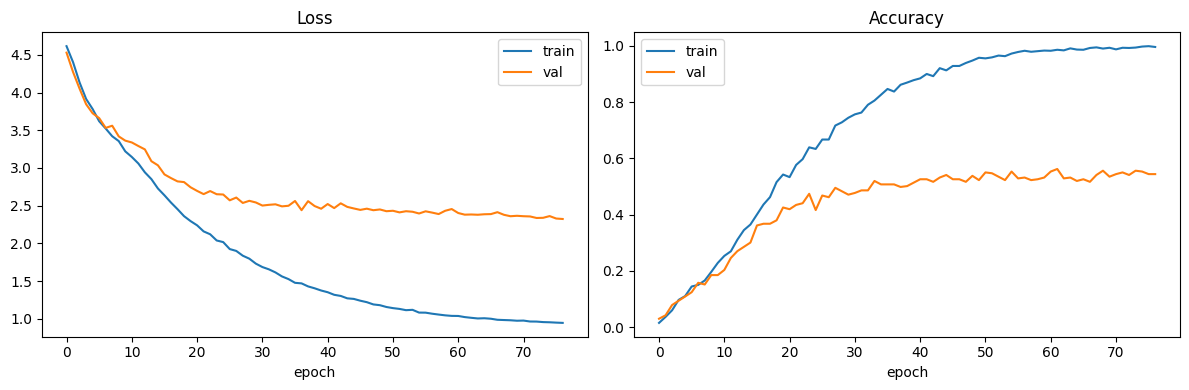

In [36]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(history['train_loss'], label='train')
axes[0].plot(history['val_loss'], label='val')
axes[0].set_title('Loss'); axes[0].set_xlabel('epoch'); axes[0].legend()

axes[1].plot(history['train_acc'], label='train')
axes[1].plot(history['val_acc'], label='val')
axes[1].set_title('Accuracy'); axes[1].set_xlabel('epoch'); axes[1].legend()

plt.tight_layout()
plt.savefig(f'{DRIVE_PROJECT_DIR}/checkpoints/training_curves.png', dpi=120)
plt.show()

## 7. Evaluation

Top-1 / top-5 accuracy plus per-class precision/recall/F1 on the held-out test split 

In [ ]:
eval_loader = test_loader if test_loader is not None else val_loader
eval_name = 'test' if test_loader is not None else 'val'
print(f'Evaluating on the {eval_name} split ({len(eval_loader.dataset)} clips)')

model.eval()
all_logits, all_labels = [], []
with torch.no_grad():
    for xb, yb in eval_loader:
        xb = xb.to(device)
        logits = model(xb)
        all_logits.append(logits.cpu())
        all_labels.append(yb)

all_logits = torch.cat(all_logits, dim=0)
all_labels = torch.cat(all_labels, dim=0)
all_probs = torch.softmax(all_logits, dim=-1)

top1_preds = all_probs.argmax(dim=-1)
top1_acc = (top1_preds == all_labels).float().mean().item()

top5_preds = all_probs.topk(k=5, dim=-1).indices
top5_acc = (top5_preds == all_labels.unsqueeze(1)).any(dim=1).float().mean().item()

print(f'Top-1 accuracy: {top1_acc:.3f}') 
print(f'Top-5 accuracy: {top5_acc:.3f}')

Evaluating on the test split (249 clips)
Top-1 accuracy: 0.550
Top-5 accuracy: 0.819


In [38]:
from sklearn.metrics import classification_report, confusion_matrix

target_names = [label_map[str(i)] for i in range(len(label_map))]
report = classification_report(
    all_labels.numpy(), top1_preds.numpy(),
    target_names=target_names, zero_division=0,
)
print(report)

with open(f'{DRIVE_PROJECT_DIR}/checkpoints/classification_report.txt', 'w') as f:
    f.write(report)

              precision    recall  f1-score   support

        book       0.67      1.00      0.80         4
       drink       0.50      0.50      0.50         4
    computer       0.33      0.80      0.47         5
      before       0.50      0.25      0.33         4
       chair       0.50      0.67      0.57         3
          go       0.50      0.67      0.57         3
     clothes       1.00      0.67      0.80         3
         who       0.33      0.33      0.33         3
       candy       0.50      0.67      0.57         3
      cousin       0.50      0.33      0.40         3
        deaf       1.00      0.67      0.80         3
        fine       0.50      0.50      0.50         2
        help       0.50      1.00      0.67         3
          no       0.33      0.33      0.33         3
        thin       0.00      0.00      0.00         3
        walk       0.67      0.67      0.67         3
        year       1.00      0.67      0.80         3
         yes       0.33    

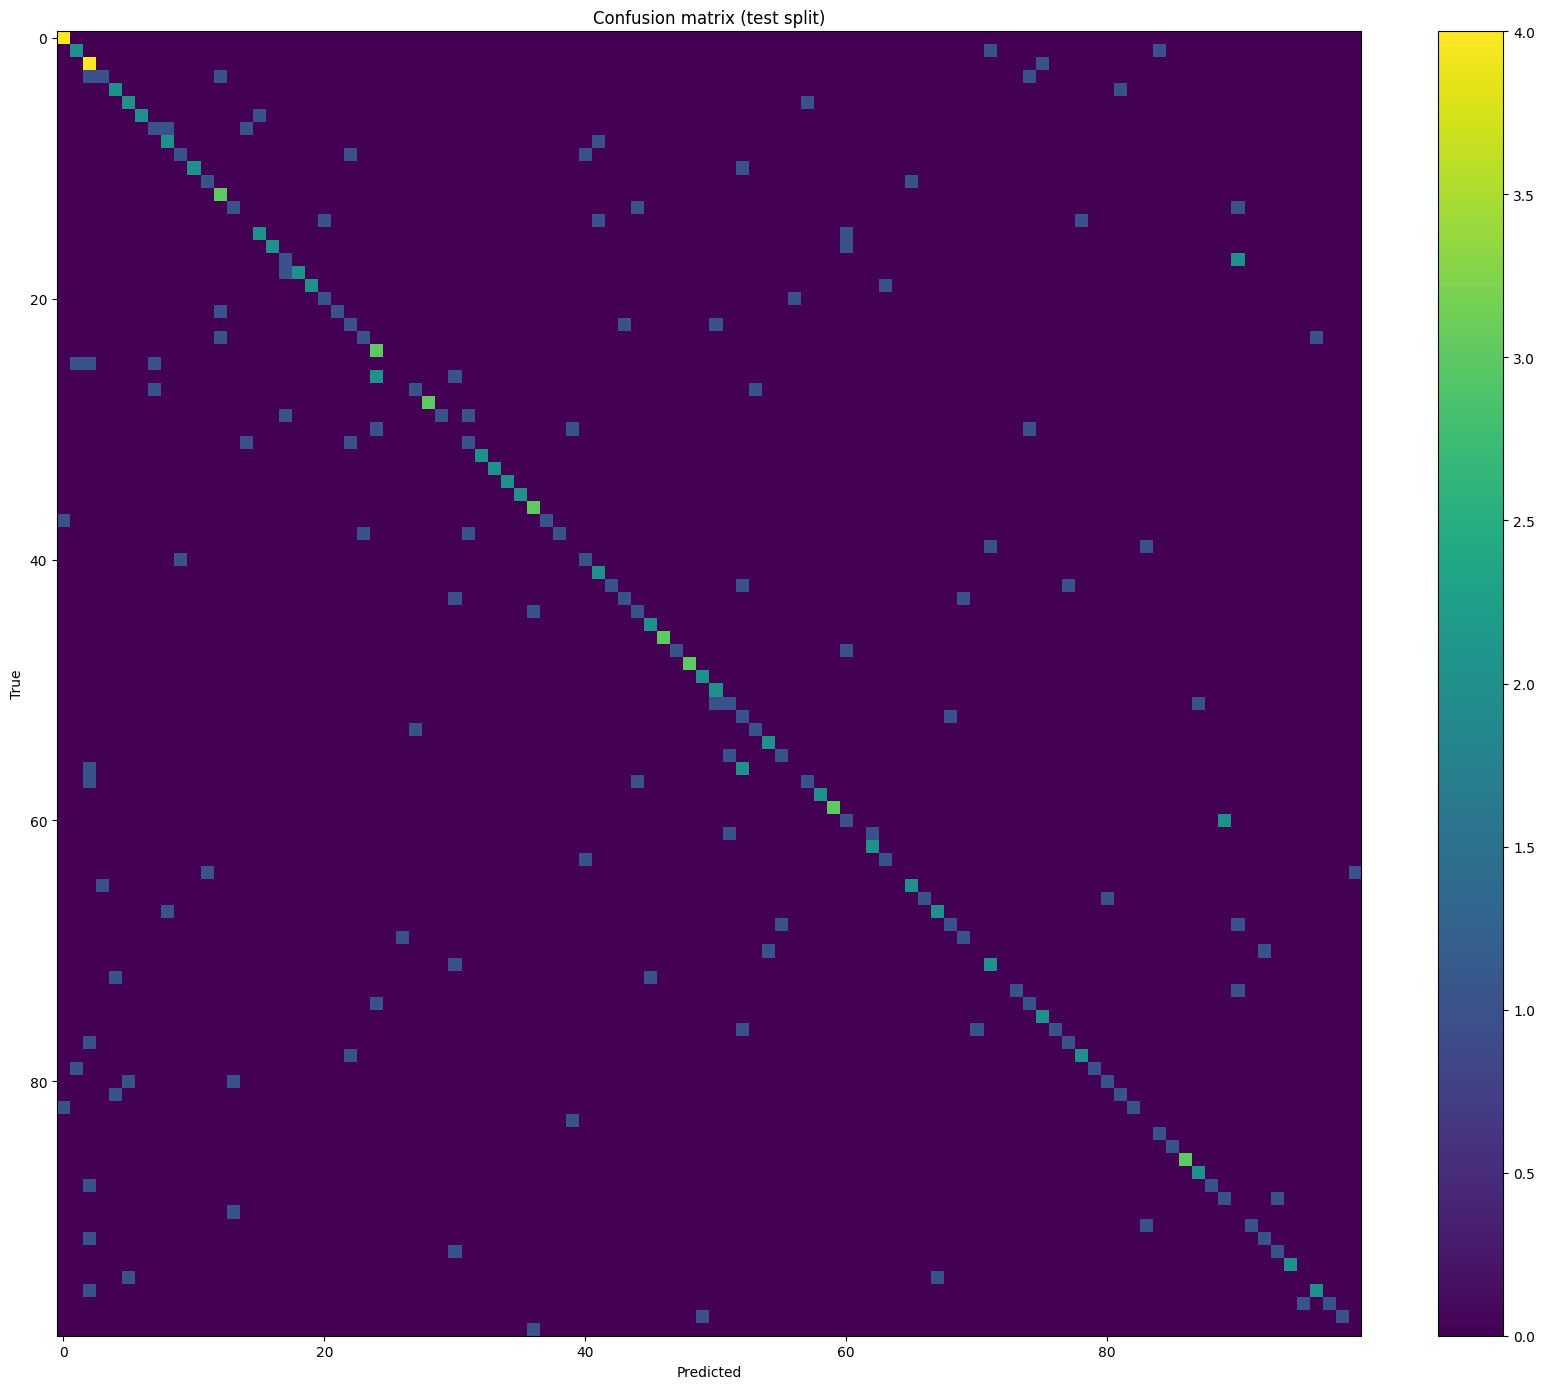

Most-confused (true -> predicted) pairs:
  corn                 -> apple                 (2 times)
  now                  -> many                  (2 times)
  doctor               -> medicine              (2 times)
  yes                  -> need                  (2 times)
  right                -> pink                  (1 times)
  accident             -> jacket                (1 times)
  hot                  -> language              (1 times)
  fish                 -> like                  (1 times)
  forget               -> hat                   (1 times)
  no                   -> need                  (1 times)
  city                 -> book                  (1 times)
  but                  -> no                    (1 times)
  fish                 -> woman                 (1 times)
  like                 -> same                  (1 times)
  graduate             -> secretary             (1 times)


In [39]:
cm = confusion_matrix(all_labels.numpy(), top1_preds.numpy())

fig, ax = plt.subplots(figsize=(16, 14))
im = ax.imshow(cm, cmap='viridis')
ax.set_xlabel('Predicted'); ax.set_ylabel('True')
ax.set_title(f'Confusion matrix ({eval_name} split)')
fig.colorbar(im, ax=ax, fraction=0.046)
plt.tight_layout()
plt.savefig(f'{DRIVE_PROJECT_DIR}/checkpoints/confusion_matrix.png', dpi=120)
plt.show()

# Most-confused class pairs (top 15 off-diagonal counts)
cm_off_diag = cm.copy()
np.fill_diagonal(cm_off_diag, 0)
flat_idx = np.argsort(cm_off_diag, axis=None)[::-1][:15]
print('Most-confused (true -> predicted) pairs:')
for idx in flat_idx:
    i, j = np.unravel_index(idx, cm_off_diag.shape)
    count = cm_off_diag[i, j]
    if count == 0:
        break
    print(f'  {target_names[i]:<20s} -> {target_names[j]:<20s}  ({int(count)} times)')

## 8. Save artifacts to Drive

The best checkpoint was already saved during training. This cell saves the remaining
artifacts the downstream pipeline needs: the label map (also embedded in the checkpoint, kept
standalone too for convenience) and a copy of the exact config used.

In [40]:
import json, shutil

with open(f'{DRIVE_PROJECT_DIR}/checkpoints/label_map.json', 'w') as f:
    json.dump(label_map, f, indent=2)

shutil.copy('config.yaml', f'{DRIVE_PROJECT_DIR}/checkpoints/config.yaml')
shutil.copy('sign_language_model.py', f'{DRIVE_PROJECT_DIR}/checkpoints/sign_language_model.py')

print('Saved to', f'{DRIVE_PROJECT_DIR}/checkpoints/:')
!ls -la {DRIVE_PROJECT_DIR}/checkpoints

Saved to /content/drive/MyDrive/wlasl100_slr/checkpoints/:
total 6209
-rw------- 1 root root 6214069 Jul  7 05:28 best_model.pt
-rw------- 1 root root    5618 Jul  7 05:31 classification_report.txt
-rw------- 1 root root    2798 Jul  7 05:33 config.yaml
-rw------- 1 root root   43137 Jul  7 05:32 confusion_matrix.png
-rw------- 1 root root    1681 Jul  7 05:33 label_map.json
-rw------- 1 root root   27472 Jul  7 05:33 sign_language_model.py
-rw------- 1 root root   61196 Jul  7 05:30 training_curves.png


## 9. Inference sanity check

Loads the just-saved checkpoint through the exact same `SignLanguageRecognizer` interface the
deployed pipeline will use (see `inference.py`), and runs it on one held-out clip end-to-end
(straight from the raw video file, not the cached features) as a final sanity check that
training → checkpoint → inference all agree.

In [41]:
sample_inst = (test_instances or val_instances)[0]
print('Ground-truth gloss:', label_map[str(sample_inst['label_index'])])

recognizer = SignLanguageRecognizer(
    checkpoint_path=CHECKPOINT_PATH,
    models_dir='models',
)
if not recognizer.ready:
    print('ERROR initializing recognizer:', recognizer.init_error)
else:
    result = recognizer.predict(sample_inst['path'], top_k=5)
    print(result)
recognizer.close()

Ground-truth gloss: shirt
{'success': True, 'predicted_class': 'shirt', 'predicted_index': 46, 'confidence': 0.4302593469619751, 'top_k': [{'class': 'shirt', 'index': 46, 'confidence': 0.4302593469619751}, {'class': 'thursday', 'index': 99, 'confidence': 0.28600168228149414}, {'class': 'last', 'index': 65, 'confidence': 0.05342423543334007}, {'class': 'before', 'index': 3, 'confidence': 0.045075420290231705}, {'class': 'dog', 'index': 36, 'confidence': 0.04098385572433472}], 'below_confidence_threshold': False, 'error': None}
